# imports

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torch.nn.functional as F
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import PIL
from PIL import Image
import albumentations as A
import seaborn as sns
import glob
from pathlib import Path
torch.manual_seed(1)
np.random.seed(1)

# Dataset

In [2]:
#data_dir = Path(r'C:\Users\danre\Documents\CNN\Peces\FishNet\data\raw\NA_Fish_Dataset')
#data_dir = Path(r'C:\Users\danre\Documents\CNN\Peces\FishNet\data_raw\Fish_Dataset\Fish_Dataset')
data_dir = Path(r'C:\Users\danre\Documents\CNN\Peces\FishNet\data\mini_dataset')
file_path = []
for ext in ['*.png', '*.jpg', '*.jpeg']:
    file_path.extend(list(data_dir.glob(f'**/{ext}')))
classes = list(map(lambda x: os.path.split(os.path.split(x)[0])[1],file_path))
                                
file_path = pd.Series(file_path).astype(str)
classes = pd.Series(classes)
df = pd.concat([file_path, classes], axis=1)
df.columns = ['image', 'label']
df = df[df['label'].apply(lambda x: x[-2:] != 'GT')]
df.head()

,image,label
0,C:\Users\danre\Documents\CNN\Peces\FishNet\dat...,Black Sea Sprat
1,C:\Users\danre\Documents\CNN\Peces\FishNet\dat...,Black Sea Sprat
2,C:\Users\danre\Documents\CNN\Peces\FishNet\dat...,Black Sea Sprat
3,C:\Users\danre\Documents\CNN\Peces\FishNet\dat...,Black Sea Sprat
4,C:\Users\danre\Documents\CNN\Peces\FishNet\dat...,Black Sea Sprat


In [3]:
lb = LabelEncoder()
df['encoded_labels'] = lb.fit_transform(df['label'])
df

,image,label,encoded_labels
0,C:\Users\danre\Documents\CNN\Peces\FishNet\dat...,Black Sea Sprat,1
1,C:\Users\danre\Documents\CNN\Peces\FishNet\dat...,Black Sea Sprat,1
2,C:\Users\danre\Documents\CNN\Peces\FishNet\dat...,Black Sea Sprat,1
3,C:\Users\danre\Documents\CNN\Peces\FishNet\dat...,Black Sea Sprat,1
4,C:\Users\danre\Documents\CNN\Peces\FishNet\dat...,Black Sea Sprat,1
...,...,...,...
1495,C:\Users\danre\Documents\CNN\Peces\FishNet\dat...,Astrolebpus,0
1496,C:\Users\danre\Documents\CNN\Peces\FishNet\dat...,Astrolebpus,0
1497,C:\Users\danre\Documents\CNN\Peces\FishNet\dat...,Astrolebpus,0
1498,C:\Users\danre\Documents\CNN\Peces\FishNet\dat...,Astrolebpus,0


# DATA SPLIT

In [4]:
train_df, test_df = train_test_split(df, train_size=0.95, random_state=0)
train_df, valid_df = train_test_split(train_df, train_size=0.9, random_state=0)
print(train_df.label.value_counts())
print(valid_df.label.value_counts())
print(test_df.label.value_counts())

label
Hourse Mackerel       133
Gilt-Head Bream       132
Sea Bass              131
Shrimp                131
Red Mullet            128
Astrolebpus           127
Red Sea Bream         127
Black Sea Sprat       126
Trout                 124
Striped Red Mullet    123
Name: count, dtype: int64
label
Black Sea Sprat       18
Trout                 17
Striped Red Mullet    16
Red Sea Bream         16
Sea Bass              15
Shrimp                14
Astrolebpus           13
Gilt-Head Bream       12
Hourse Mackerel       12
Red Mullet            10
Name: count, dtype: int64
label
Red Mullet            12
Striped Red Mullet    11
Astrolebpus           10
Trout                  9
Red Sea Bream          7
Black Sea Sprat        6
Gilt-Head Bream        6
Hourse Mackerel        5
Shrimp                 5
Sea Bass               4
Name: count, dtype: int64


# Dataset class

In [5]:
class FishDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=transforms.Compose([transforms.ToTensor()])):
        self.df = df
        self.transform = transform
        
    def __len__(self):
        length = len(self.df)
        return length
        
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx, 0]
        label = self.df.iloc[idx, 2]
        label = int(label)
        label = torch.tensor(label)
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        return image, label

In [6]:
data_transforms = transforms.Compose([
    transforms.Resize([224, 224]),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
data_transforms_test = transforms.Compose([
    transforms.Resize([224, 224]),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

In [7]:
train_dataset = FishDataset(df=train_df, transform=data_transforms)
valid_dataset = FishDataset(df=valid_df, transform=data_transforms_test)
test_dataset = FishDataset(df=test_df, transform=data_transforms_test)

In [8]:
batch_size = 64

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=len(test_dataset))

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device
print(device)  # Debería mostrar "cuda:0"
print(torch.cuda.is_available())  # Debería ser True

cuda:0
True


# MODELO

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1))
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(kernel_size=2, stride=2))
        
        self.fc = nn.Sequential(
            nn.Linear(32 * 112 * 112, 10),
            nn.Dropout(0.2),
            nn.BatchNorm1d(10),
            nn.LeakyReLU(0.01, True))
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(-1, 32 * 112 * 112)
        x = self.fc(x)
        return x

# Entrenamiento


In [11]:
#From https://github.com/Bjarten/early-stopping-pytorch
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=7, verbose=False):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
                            Default: 7
            verbose (bool): If True, prints a message for each validation loss improvement. 
                            Default: False
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf

    def __call__(self, val_loss, model):

        score = -val_loss

        if self.best_score is None:
            self.best_score = score
#             self.save_checkpoint(val_loss, model)
        elif score < self.best_score:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
#             self.save_checkpoint(val_loss, model)
            self.counter = 0

#     def save_checkpoint(self, val_loss, model):
#         '''Saves model when validation loss decrease.'''
#         if self.verbose:
#             print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
#         torch.save(model.state_dict(), 'checkpoint.pt')
#         self.val_loss_min = val_loss

In [12]:
model = SimpleCNN()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

criterion = nn.CrossEntropyLoss()

lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1, patience=2, cooldown=2, verbose=True)

model = model.to(device)
criterion = criterion.to(device)

c:\Users\danre\miniconda3\envs\vision\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [19]:
epochs = 30

total_train_loss = []
total_valid_loss = []
best_valid_loss = np.Inf
early_stop = EarlyStopping(patience=5, verbose=True)

for epoch in range(epochs): 
    print('Epoch: ', epoch + 1)
    train_loss = []
    valid_loss = []
    train_correct = 0
    train_total = 0
    valid_correct = 0
    valid_total = 0
    for image, target in train_loader:
        model.train()
        image, target = image.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, target)
        train_loss.append(loss.item())
        _, predicted = torch.max(output.data, 1)
        train_total += target.size(0)
        train_correct += (predicted == target).sum().item()
        
        loss.backward()
        optimizer.step()
        
    for image, target in valid_loader:
        with torch.no_grad():
            model.eval()
            image, target = image.to(device), target.to(device)
            
            output = model(image)
            loss = criterion(output, target)
            valid_loss.append(loss.item())
            _, predicted = torch.max(output.data, 1)
            valid_total += target.size(0)
            valid_correct += (predicted == target).sum().item()
            
    epoch_train_loss = np.mean(train_loss)
    epoch_valid_loss = np.mean(valid_loss)
    print(f'Epoch {epoch + 1}, train loss: {epoch_train_loss:.4f}, valid loss: {epoch_valid_loss:.4f}, train accuracy: {(100 * train_correct / train_total):.4f}%, valid accuracy: {(100 * valid_correct / valid_total):.4f}%')
    if epoch_valid_loss < best_valid_loss:
        torch.save(model.state_dict(), 'fish_classification_model.pt')
        print('Model improved. Saving model.')
        best_valid_loss = epoch_valid_loss
    
    early_stop(epoch_valid_loss, model)
        
    if early_stop.early_stop:
        print("Early stopping")
        break
        
    lr_scheduler.step(epoch_valid_loss)
    total_train_loss.append(epoch_train_loss)
    total_valid_loss.append(epoch_valid_loss)

Epoch:  1
Epoch 1, train loss: 0.7906, valid loss: 0.6544, train accuracy: 82.9953%, valid accuracy: 97.9021%
Model improved. Saving model.
Epoch:  2
Epoch 2, train loss: 0.7930, valid loss: 0.6474, train accuracy: 83.7754%, valid accuracy: 97.9021%
Model improved. Saving model.
Epoch:  3
Epoch 3, train loss: 0.7718, valid loss: 0.6517, train accuracy: 85.1014%, valid accuracy: 98.6014%
EarlyStopping counter: 1 out of 5
Epoch:  4
Epoch 4, train loss: 0.7767, valid loss: 0.6601, train accuracy: 86.3495%, valid accuracy: 97.9021%
EarlyStopping counter: 2 out of 5
Epoch:  5
Epoch 5, train loss: 0.7760, valid loss: 0.6437, train accuracy: 85.0234%, valid accuracy: 99.3007%
Model improved. Saving model.
Epoch:  6
Epoch 6, train loss: 0.7674, valid loss: 0.6508, train accuracy: 85.7254%, valid accuracy: 99.3007%
EarlyStopping counter: 1 out of 5
Epoch:  7
Epoch 7, train loss: 0.7673, valid loss: 0.6680, train accuracy: 84.4774%, valid accuracy: 98.6014%
EarlyStopping counter: 2 out of 5
Epoc

# PREDICTIONS


In [14]:
model.load_state_dict(torch.load('fish_classification_model.pt'))

correct = 0
total = 0

with torch.no_grad():
    model.eval()
    for image, target in test_loader:
        image, target = image.to(device), target.to(device)
        
        output = model(image)
        
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

print('Test Accuracy: %d %%' % (
    100 * correct / total))

C:\Users\danre\AppData\Local\Temp\ipykernel_21360\1153662060.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('fish_classification_model.

Test Accuracy: 98 %


# EVALUACION


C:\Users\danre\AppData\Local\Temp\ipykernel_21360\1011652164.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('fish_classification_model.

Test Accuracy: 98.67%

Classification Report:
                    precision    recall  f1-score   support

       Astrolebpus       1.00      1.00      1.00        10
   Black Sea Sprat       1.00      1.00      1.00         6
   Gilt-Head Bream       0.86      1.00      0.92         6
   Hourse Mackerel       1.00      1.00      1.00         5
        Red Mullet       1.00      1.00      1.00        12
     Red Sea Bream       1.00      1.00      1.00         7
          Sea Bass       1.00      0.75      0.86         4
            Shrimp       1.00      1.00      1.00         5
Striped Red Mullet       1.00      1.00      1.00        11
             Trout       1.00      1.00      1.00         9

          accuracy                           0.99        75
         macro avg       0.99      0.97      0.98        75
      weighted avg       0.99      0.99      0.99        75



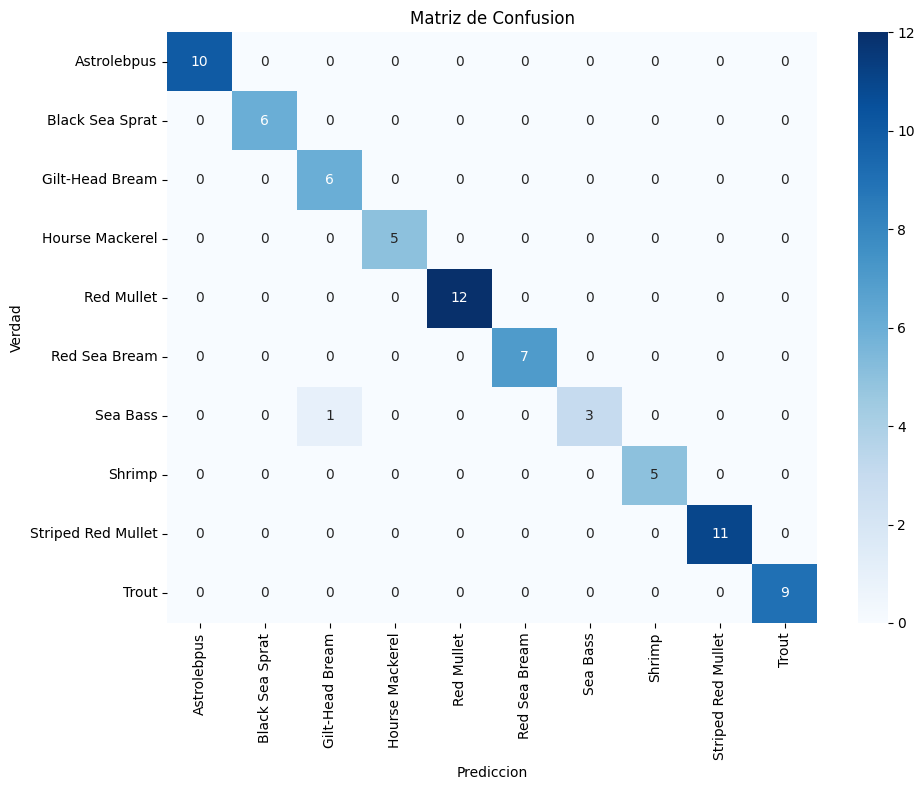

In [20]:
model.load_state_dict(torch.load('fish_classification_model.pt'))
model = model.to(device)

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    model.eval()
    for image, target in test_loader:
        image, target = image.to(device), target.to(device)
        output = model(image)
        probs = F.softmax(output, dim=1)
        _, predicted = torch.max(output.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(target.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

from sklearn.metrics import classification_report, confusion_matrix

print('Test Accuracy: %.2f%%' % (100 * np.mean(y_true == y_pred)))
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=lb.classes_))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lb.classes_, yticklabels=lb.classes_, ax=ax)
ax.set_xlabel('Prediccion')
ax.set_ylabel('Verdad')
ax.set_title('Matriz de Confusion')
plt.tight_layout()
plt.show()


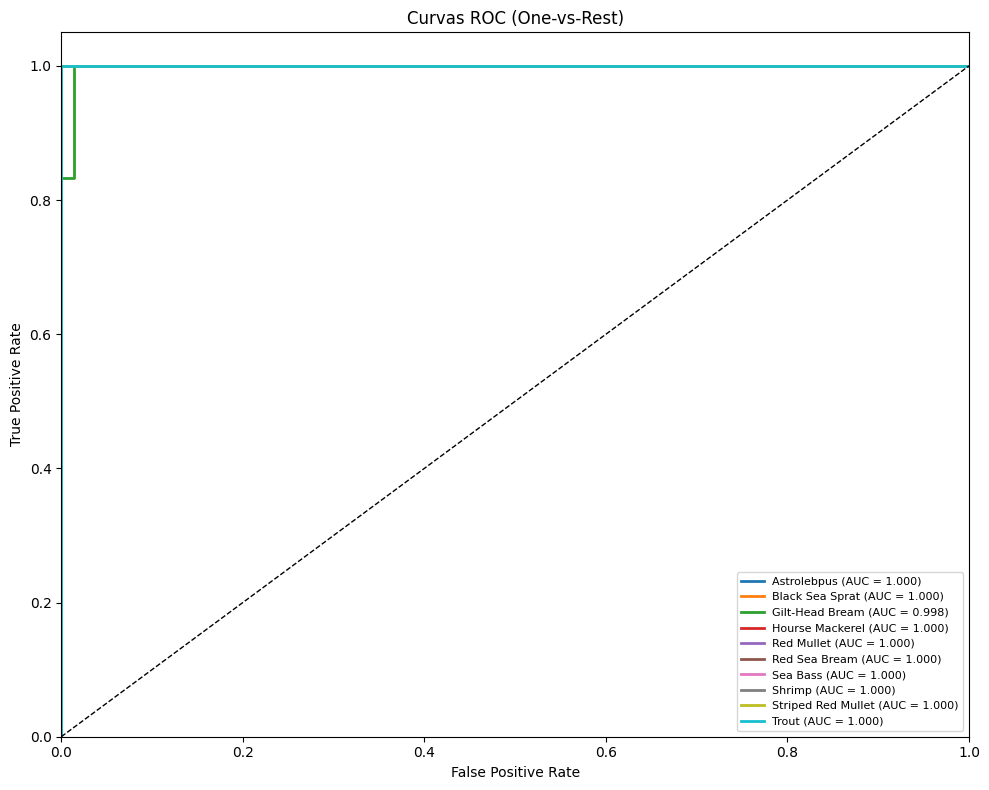

In [16]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(lb.classes_)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

fig, ax = plt.subplots(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f'{lb.classes_[i]} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC (One-vs-Rest)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


# GRAD-CAM


C:\Users\danre\AppData\Local\Temp\ipykernel_21360\798150143.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('fish_classification_model.


Ejemplo 1: 00197.png


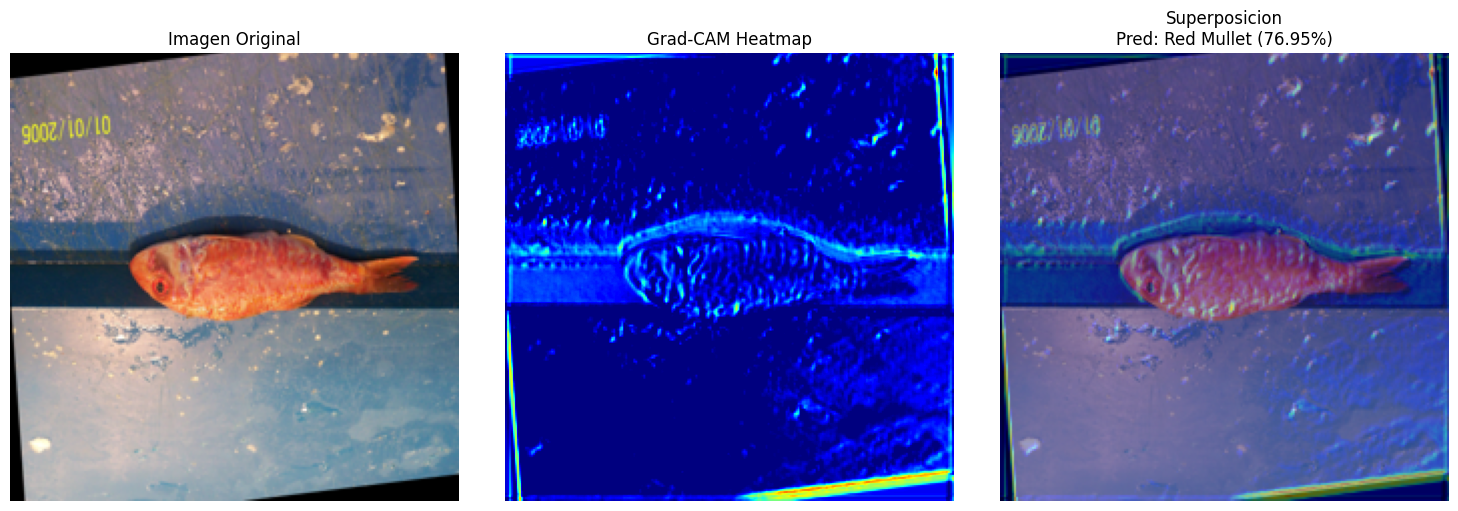


Ejemplo 2: 00061.png


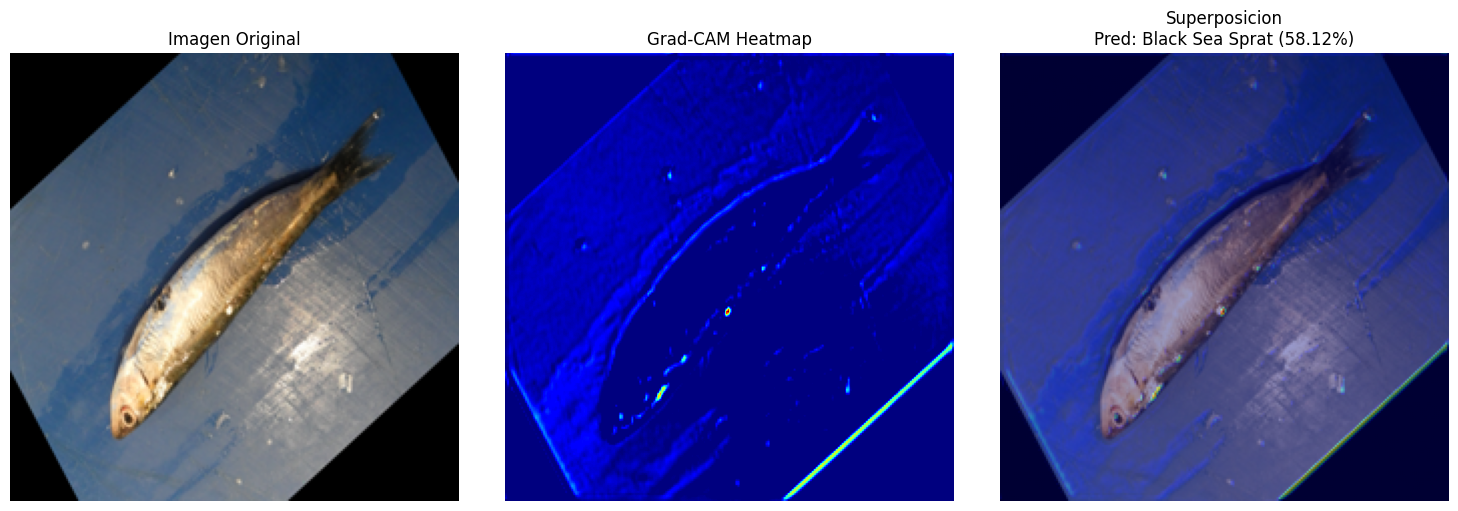


Ejemplo 3: sin_especie_0143_aug00.jpeg


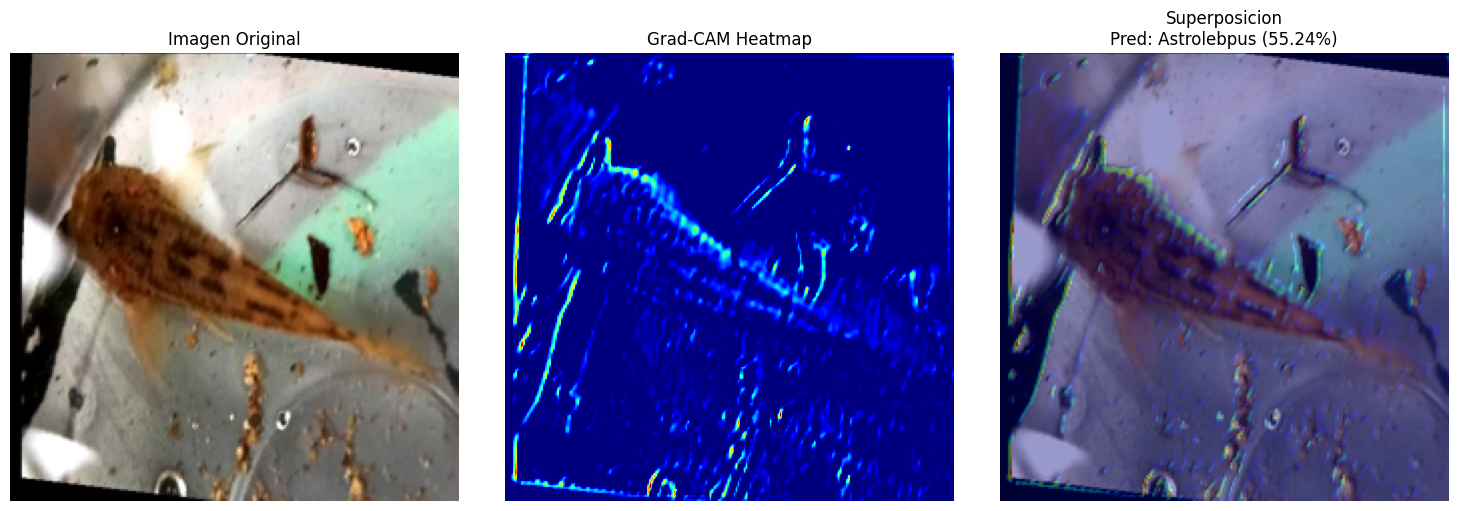


Ejemplo 4: 00349.png


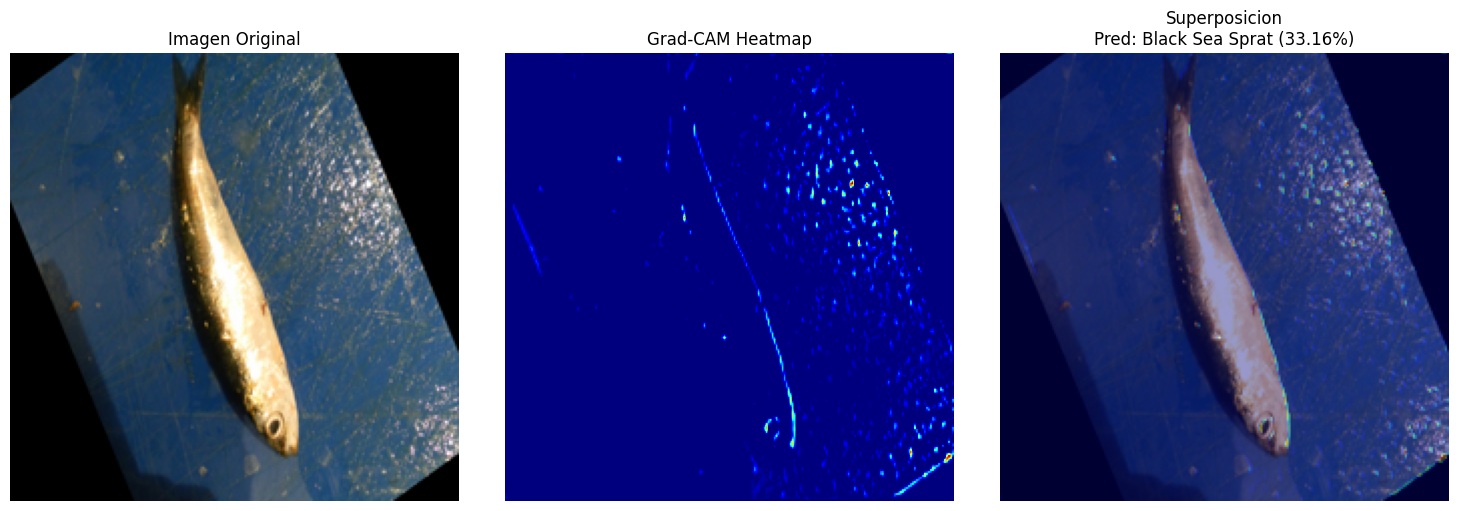


Ejemplo 5: sin_especie_0065_aug01.jpg


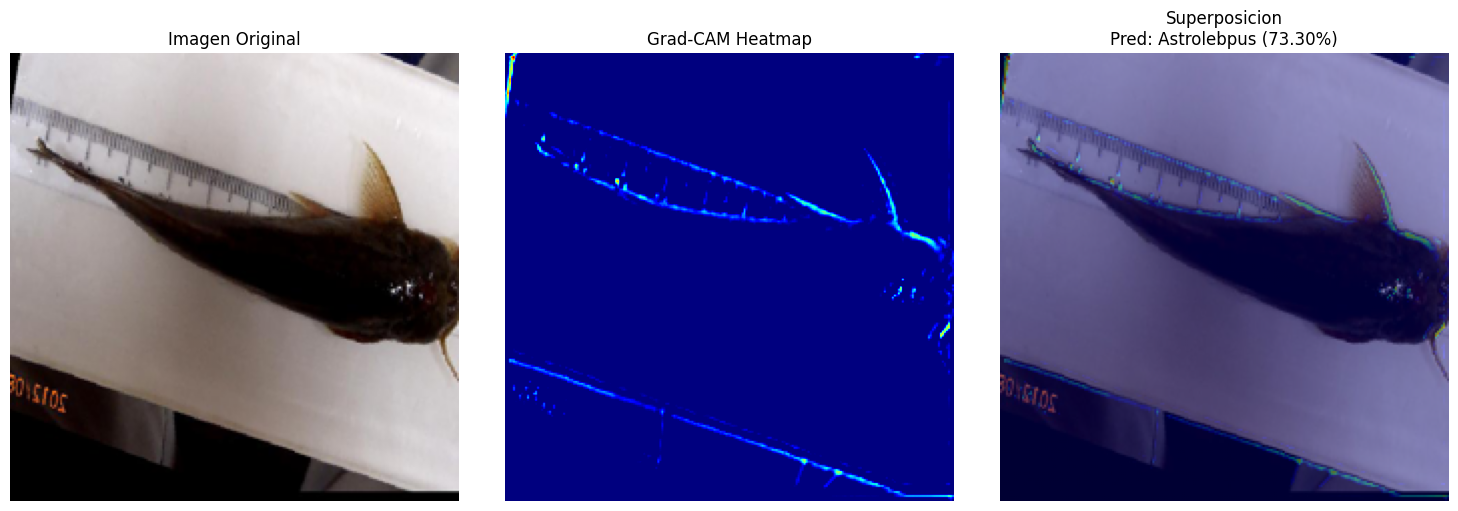


Ejemplo 6: 00711.png


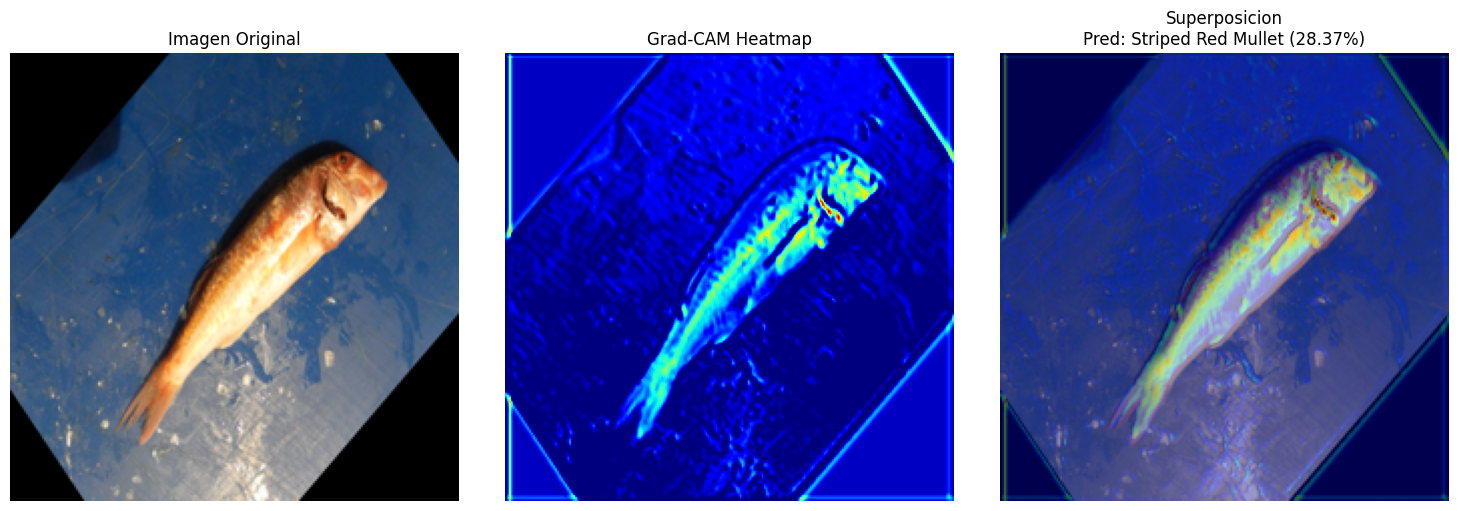

In [18]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()
    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)
    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        pooled_grads = self.gradients.mean(dim=(2, 3), keepdim=True)
        heatmap = (self.activations * pooled_grads).sum(dim=1, keepdim=True)
        heatmap = F.relu(heatmap)
        heatmap = heatmap / (heatmap.max() + 1e-8)
        return heatmap.squeeze().cpu().numpy(), class_idx

def find_last_conv(model):
    last_conv = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module
    return last_conv

def display_gradcam(image_path, model, class_names, alpha=0.4):
    from PIL import Image
    original = Image.open(image_path).convert('RGB').resize((224, 224))
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    input_tensor = transform(original).unsqueeze(0).to(device)
    last_conv = find_last_conv(model)
    if last_conv is None:
        print('  No se encontro capa Conv2d')
        return None, None, None
    gradcam = GradCAM(model, last_conv)
    heatmap, pred_class = gradcam.generate(input_tensor)
    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)
        confidence = probs[0, pred_class].item()
    heatmap_resized = np.array(Image.fromarray(heatmap).resize((224, 224), Image.BILINEAR))
    img_display = np.array(original) / 255.0
    heatmap_colored = plt.cm.jet(heatmap_resized)[:, :, :3]
    superimposed = (1 - alpha) * img_display + alpha * heatmap_colored
    superimposed = np.clip(superimposed, 0, 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_display)
    axes[0].set_title('Imagen Original')
    axes[0].axis('off')
    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')
    axes[2].imshow(superimposed)
    axes[2].set_title(f'Superposicion\nPred: {class_names[pred_class]} ({confidence:.2%})')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()
    return pred_class, confidence, heatmap

model.load_state_dict(torch.load('fish_classification_model.pt'))
model = model.to(device)

n_samples = min(6, len(test_df))
paths = test_df.iloc[:n_samples, 0].tolist()

for i, fpath in enumerate(paths):
    print(f'\nEjemplo {i+1}: {Path(fpath).name}')
    try:
        display_gradcam(fpath, model, lb.classes_)
    except Exception as e:
        print(f'  Error: {e}')
